# Colab 환경에서 실행 시 환경 설정

구글 드라이브의 폴더와 구글 코랩 폴더 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

### 코랩에서 한국어 표시하기

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import koreanize_matplotlib

<a id="lecture_index"></a>
# 🔖 사전학습 모델 활용하기 & 자연어 처리 기초

# 수업 목차
[1. 복습](#one)<br>
        
[2. 사전학습 모델 활용법](#two)<br>
- 사전학습 모델 개념
- 사전학습 모델 찾는 법
- 사전학습 모델 불러오기
- 사전학습 모델을 활용한 추론

[3. 사전학습 모델을 활용한 전이 학습](#three)<br>
- 전이학습 개념 
- 특징 추출
- 디버깅 방법  
- 미세 조정

[4. 분류 모델 미니 프로젝트](#four)<br>
- 데이터 수집 부터 모델 학습까지 

[5. 자연어 처리 개요](#five)<br>
- 자연어 처리란? 
- 자연어 처리의 발전 흐름 
- 자연어 처리 작업 분류 

# <a id='one'>1️⃣ 복습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 🧩 Quiz 1

- Dataset
- Dataloader
- 데이터 증강
- ResNet 
- 사전학습 모델

### Dataset
- getitem 메소드를 내가 원하는대로 구현해서 데이터를 불러온다
- 클래스이기 떄문에 내가 원하는 방색대로 데이터를 불러오도록 구현한다.
- 필터링 기능 추가 가능
- 데이터 셋의 경로를 저장한다

In [1]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
from sklearn import datasets


full_dataset = datasets.ImageFolder(root='dataset5', transform=transform)

In [3]:
cd

C:\Users\human


In [4]:
import os

root_path = '.\\KU-PYTHON\\Ch19\\dataset5\\train'
for folder in os.listdir(root_path):
    for file in os.listdir(root_path + '\\' + folder):
        print(root_path + folder + file)

.\KU-PYTHON\Ch19\dataset5\traincat0.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1.jpg
.\KU-PYTHON\Ch19\dataset5\traincat10.jpg
.\KU-PYTHON\Ch19\dataset5\traincat100.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1000.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1001.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1002.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1003.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1004.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1005.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1006.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1007.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1008.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1009.jpg
.\KU-PYTHON\Ch19\dataset5\traincat101.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1010.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1011.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1012.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1013.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1014.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1015.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1016.jpg
.\KU-PYTHON\Ch19\dataset5\traincat1017.jpg
.\KU-PYTHON\Ch19\data

In [6]:
for k, v in enumerate(os.listdir(root_path)):
    print(k, v)

0 cat
1 dog


In [5]:
from glob import glob

file_list = glob(root_path + '/*/*.jpg')

In [50]:
file_list

['.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\0.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\10.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\100.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1000.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1001.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1002.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1003.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1004.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1005.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1006.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1007.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1008.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1009.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\101.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1010.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1011.jpg',
 '.\\KU-PYTHON\\Ch19\\dataset5\\train\\cat\\1012.jpg',
 '.\\KU-PYTHON\\Ch19

In [51]:
file_list[0].split('\\')[5]

'cat'

In [7]:
# 기본 Dataset 클래스 생성

class FoodDataset(Dataset):
    def __init__(self, root, transform):
        self.root_path = None   # 데이터셋의 루트 경로
        self.image_path = []    # 이미지 경로 리스트
        self.label_path = []    # 레이블 경로 리스트
        self.class_to_idx = {}  # 클래스 인덱스 딕셔너리
        self.error_path = []    # 오류 경로 리스트
        self.transform = transform # 변환 함수
        
    
    def __getitem__(self):
        pass

In [8]:
from PIL import Image
import numpy as np

# DataLoader를 사용하기 위한 Dataset 클래스 생성
# 반드시 __getitem__과 __len__ 메서드를 구현해야 함
class FoodDataset(Dataset):
    def __init__(self, root, transform):
        self.root_path = root
        self.image_path = glob(root_path + '/*/*.jpg')  # 유효한 이미지만 필터링
        self.label_path = [file.split('\\')[5] for file in self.image_path]
        self.class_to_idx = {k:v for k, v in enumerate(os.listdir(root_path))}
        self.error_path = []
        self.transform = transform
        
    
    def __getitem__(self, index):
        images, labels = self.image_path[index], self.label_path[index]
        images = Image.open(images)
        images = self.transform(images) # transform에는 PIL 이미지를 넘긴다.
        labels = self.class_to_idx
        
        return images, labels
    
    def __len__(self):
        return len(self.image_path)

In [9]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),    # 이미지 크기 조정
    transforms.ToTensor(),  # 이미지 텐서로 변환 -> 0 ~ 255 사이의 값을 0 ~ 1 사이로 변환
])

dataset = FoodDataset('.\\KU-PYTHON\\Ch19\\dataset5\\train', transform)

# DataLoader - dataset, batch_size, shuffle
# DataLoader는 Dataset을 반복할 수 있는 객체로 변환
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [89]:
img, label = dataset.__getitem__(1)

In [90]:
img

tensor([[[0.2118, 0.1804, 0.2667,  ..., 0.3137, 0.3216, 0.3333],
         [0.1647, 0.1608, 0.2588,  ..., 0.2510, 0.2745, 0.3059],
         [0.1412, 0.1569, 0.2510,  ..., 0.2392, 0.2588, 0.2902],
         ...,
         [0.0784, 0.0784, 0.0706,  ..., 0.3373, 0.3765, 0.3686],
         [0.0902, 0.0863, 0.0824,  ..., 0.2941, 0.3373, 0.3294],
         [0.1020, 0.0980, 0.0902,  ..., 0.2824, 0.3255, 0.3255]],

        [[0.2314, 0.2000, 0.2863,  ..., 0.3255, 0.3333, 0.3451],
         [0.1843, 0.1804, 0.2784,  ..., 0.2706, 0.2941, 0.3255],
         [0.1608, 0.1765, 0.2706,  ..., 0.2588, 0.2784, 0.3098],
         ...,
         [0.0784, 0.0784, 0.0706,  ..., 0.2824, 0.3216, 0.3137],
         [0.0902, 0.0863, 0.0824,  ..., 0.2392, 0.2824, 0.2745],
         [0.1020, 0.0980, 0.0902,  ..., 0.2275, 0.2706, 0.2706]],

        [[0.2471, 0.2157, 0.3020,  ..., 0.4000, 0.4078, 0.4196],
         [0.2000, 0.1961, 0.2941,  ..., 0.3451, 0.3686, 0.4000],
         [0.1765, 0.1922, 0.2863,  ..., 0.3412, 0.3569, 0.

In [91]:
dataloader # 순회 반복 가능한 객체 iterable -> for문, iter + next로 내용물 접근

In [10]:
image, label = next(iter(dataloader))

In [11]:
label

{0: ['cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat',
  'cat'],
 1: ['dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog',
  'dog']}

In [12]:
image

tensor([[[[0.1020, 0.1020, 0.1059,  ..., 0.1176, 0.1176, 0.1176],
          [0.1020, 0.1020, 0.1020,  ..., 0.1255, 0.1255, 0.1216],
          [0.0980, 0.0980, 0.1020,  ..., 0.1059, 0.1059, 0.1059],
          ...,
          [0.0745, 0.0863, 0.0784,  ..., 0.6745, 0.7569, 0.7882],
          [0.0784, 0.0941, 0.0863,  ..., 0.6784, 0.7608, 0.7922],
          [0.0824, 0.0941, 0.0902,  ..., 0.6824, 0.7647, 0.7961]],

         [[0.0353, 0.0353, 0.0392,  ..., 0.0196, 0.0196, 0.0196],
          [0.0353, 0.0353, 0.0353,  ..., 0.0275, 0.0275, 0.0235],
          [0.0314, 0.0314, 0.0353,  ..., 0.0078, 0.0078, 0.0078],
          ...,
          [0.0078, 0.0118, 0.0000,  ..., 0.6314, 0.7176, 0.7490],
          [0.0118, 0.0196, 0.0078,  ..., 0.6353, 0.7216, 0.7529],
          [0.0157, 0.0196, 0.0118,  ..., 0.6392, 0.7255, 0.7569]],

         [[0.0039, 0.0039, 0.0078,  ..., 0.0392, 0.0353, 0.0353],
          [0.0039, 0.0039, 0.0039,  ..., 0.0431, 0.0431, 0.0392],
          [0.0000, 0.0000, 0.0039,  ..., 0

In [15]:
image.shape,

(torch.Size([32, 3, 224, 224]),)

#### VGG
    - 3 * 3 커널을 갖는 conv layer -> 파라미터 수가 적고, 대신 layer를 더 깊게 쌓을 수 있다.
    - 증강 -> 이미지 원본 비율을 유지하면서 resize 한다
    - 구조가 간단해서 백본으로 자주 쓴다 (Feature Extractor)

#### ResNet
    - Shortcut connection (Skip connection) 
    - 잔차 학습 (불필요한 가중치 업데이트를 최소화 해준다)
    - 입력층으로 갈수록 미분값이 줄어드는 것을 막아준다
    - BottleNeck 구조
    - 1 * 1 convolution layer를 활용
    - Adaptive average pooling
    - 증강 -> Multi Scale Training
    랜덤한 크기의 이미지로 resize 해서 증강하는 방식

##### 사전학습 모델
-> 대규모 데이터 셋으로 이미 검증된  성능을 보이는 학습된 모델
<br>
사전학습 모델을 활용해서 기존의 작업을 새로운 작업으로 해주는 작업 -> 전이학습

- Fine-Tuning
- 특징 추출

# <a id='two'>2️⃣ 사전학습 모델 활용법</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

# 사전학습 모델

> 사전학습 모델(pre-trained model)은 대규모 데이터로 사전에 학습된 신경망 모델 <br>
> 일반적으로 이 모델들은 특정 작업이나 데이터셋에 최적화되기 전에, 일반적인 패턴이나 특징을 학습함

참고: https://pytorch.org/vision/stable/models.html

## 사전학습 모델 찾는 법

In [16]:
from timm import list_models # pip install timm

all_models = list_models()

In [17]:
all_models

['aimv2_1b_patch14_224',
 'aimv2_1b_patch14_336',
 'aimv2_1b_patch14_448',
 'aimv2_3b_patch14_224',
 'aimv2_3b_patch14_336',
 'aimv2_3b_patch14_448',
 'aimv2_huge_patch14_224',
 'aimv2_huge_patch14_336',
 'aimv2_huge_patch14_448',
 'aimv2_large_patch14_224',
 'aimv2_large_patch14_336',
 'aimv2_large_patch14_448',
 'bat_resnext26ts',
 'beit_base_patch16_224',
 'beit_base_patch16_384',
 'beit_large_patch16_224',
 'beit_large_patch16_384',
 'beit_large_patch16_512',
 'beitv2_base_patch16_224',
 'beitv2_large_patch16_224',
 'botnet26t_256',
 'botnet50ts_256',
 'caformer_b36',
 'caformer_m36',
 'caformer_s18',
 'caformer_s36',
 'cait_m36_384',
 'cait_m48_448',
 'cait_s24_224',
 'cait_s24_384',
 'cait_s36_384',
 'cait_xs24_384',
 'cait_xxs24_224',
 'cait_xxs24_384',
 'cait_xxs36_224',
 'cait_xxs36_384',
 'coat_lite_medium',
 'coat_lite_medium_384',
 'coat_lite_mini',
 'coat_lite_small',
 'coat_lite_tiny',
 'coat_mini',
 'coat_small',
 'coat_tiny',
 'coatnet_0_224',
 'coatnet_0_rw_224',
 'coa

## 사전학습 모델 불러오기

In [19]:
import pandas as pd
data = {
    "항목": [
        "목적", "결과", "가중치 적용", "전처리 접근", "유용한 상황", "활용 추천", "유연성",
    ],
    "get_model()": [
        "모델 구조 + 가중치 로딩",
        "nn.Module",
        '"DEFAULT" or Enum 지정',
        ".transforms() 가능",
        "표준적이고 깔끔한 사용",
        "⭐⭐⭐⭐⭐",
        "🟡 중간",
    ],
    "get_weight()": [
        "가중치 enum 객체만 가져옴",
        "Weights Enum 객체",
        "적용은 직접 해야 함",
        ".transforms() 포함",
        "가중치가 언제, 어떻게 학습되었는지 자세한 정보가 필요할 때",
        "⭐⭐⭐⭐☆",
        "🔴 낮음",
    ],
    "get_model_weights()": [
        "모델의 가중치 enum 목록 조회",
        "Enum 리스트",
        "적용은 직접 해야 함",
        "각 enum에 대해 접근 가능",
        "여러 가중치 비교 시",
        "⭐⭐⭐☆☆",
        "❌ 매우 낮음",
    ],
    "torch.hub.load()": [
        "GitHub 저장소에서 불러오기",
        "nn.Module",
        "weights='enum 단, 저장소마다 기본 가중치는 다름",
        "직접 구현 필요",
        "외부 논문/커스텀 모델 사용",
        "⭐⭐☆☆☆",
        "🚀 매우 높음",
    ],
    "클래스 방식 (models.resnet18)": [
        "모델 클래스 직접 불러오기",
        "nn.Module",
        "weights='enum'",
        "대부분 수동 구현",
        "기존 코드를 그대로 따라하거나 특정 레이어만 간단하게 수정해서 쓸 때",
        "⭐⭐⭐☆☆",
        "🟠 약간 높음",
    ],
    "Hugging Face 방식": [
        "Transformer, ViT 등 최신 모델 로딩",
        "HuggingFace 모델 객체",
        ".from_pretrained()",
        "자동 제공 (tokenizer 등)",
        "최신 모델을 불러오거나 바로 추론하거나 fine-tuning을 하고 싶을 때",
        "⭐⭐⭐⭐☆",
        "🟢 높음",
    ]
}
df1 = pd.DataFrame(data)

In [20]:
import plotly.graph_objects as go # pip install plotly / pip install --upgrade nbformat

def show_table(df, width, height):
    header = list(df.columns)
    cells = [df[col] for col in df.columns]

    fig = go.Figure(data=[go.Table(
        header=dict(values=header, fill_color='paleturquoise', align='left'),
        cells=dict(values=cells, fill_color='lavender', align='left'))
    ])

    fig.update_layout(
        autosize=True,
        margin=dict(l=10, r=10, t=10, b=10),
        width=width,
        height=height
    )
    fig.show()

In [21]:
show_table(df1, 1000, 350)

✅ enum
```
:정해진 값 외에는 바뀌지 않는 이름들의 집합
여기서 말하는 enum은 모델의 이름 집합
ex) vgg16, resnet50 등...
```

```
⭐⭐⭐⭐⭐: 실무, 연습 모두 추천 (공식 표준)
⭐⭐⭐⭐: 추천하는 방식이지만 약간의 제약/주의가 필요
⭐⭐⭐: 상황에 따라 쓰면 유용. 보조용으로 적합
⭐⭐: 고급 사용자에게 추천. 문서나 코드 구조를 분석할 수 있는 경우 사용
```

In [22]:
import torch
from torchvision.models import get_model, get_weight, get_model_weights, resnet50, ResNet50_Weights

vgg16 = get_model("vgg16", weights=None)
pretrained_vgg16 = get_model("vgg16", weights="DEFAULT")

resnet50_enum = get_weight('ResNet50_Weights.DEFAULT') # ResNet50_Weights.DEFAULT와 동일 (Enum 객체)

# accuracy 76.130%
resnet1 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    
# repo_or_dir: Github 주소 + 태그(버전)
# model: 모델 이름
# force_reload=True -> 캐시된 모델을 가져오지 않고 최신으로 가져옴
# trust_repo: pytorch 저장소가 아닌 다른 저장소로 부터 다운 받을 때 사용
# 단, github 저장소 안에 hubconf.py 파일이 있는 경우만 다운로드 가능
resnet18 = torch.hub.load("pytorch/vision:v0.14.0", "resnet18")    

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\human/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:09<00:00, 11.0MB/s]
Downloading: "https://github.com/pytorch/vision/zipball/v0.14.0" to C:\Users\human/.cache\torch\hub\v0.14.0.zip


In [23]:
data = get_model_weights('resnet50')

In [24]:
for name in data:
    print(name)

ResNet50_Weights.IMAGENET1K_V1
ResNet50_Weights.IMAGENET1K_V2


In [ ]:
# torchvision.models에서 제공하는 모델들
# 두 코드 모두 동일한 결과를 출력함
import torchvision.models as models 

dir(models)  # 모델

from torchvision.models import list_models

models = list_models() # torchvision에서 제공하는 모델들을 리스트로 제공
models


['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [41]:
# 정규식으로 특정 모델 찾기
from torchvision.models import list_models
import torchvision.models as models
import re


mobilenet_models = [name for name in all_models if re.search('mobilenet', name)]
text = 'mobilenet_v2'
re.findall('mobilenet', text)
mobilenet_models

['mobilenet_edgetpu_100',
 'mobilenet_edgetpu_v2_l',
 'mobilenet_edgetpu_v2_m',
 'mobilenet_edgetpu_v2_s',
 'mobilenet_edgetpu_v2_xs',
 'mobilenetv1_100',
 'mobilenetv1_100h',
 'mobilenetv1_125',
 'mobilenetv2_035',
 'mobilenetv2_050',
 'mobilenetv2_075',
 'mobilenetv2_100',
 'mobilenetv2_110d',
 'mobilenetv2_120d',
 'mobilenetv2_140',
 'mobilenetv3_large_075',
 'mobilenetv3_large_100',
 'mobilenetv3_large_150d',
 'mobilenetv3_rw',
 'mobilenetv3_small_050',
 'mobilenetv3_small_075',
 'mobilenetv3_small_100',
 'mobilenetv4_conv_aa_large',
 'mobilenetv4_conv_aa_medium',
 'mobilenetv4_conv_blur_medium',
 'mobilenetv4_conv_large',
 'mobilenetv4_conv_medium',
 'mobilenetv4_conv_small',
 'mobilenetv4_conv_small_035',
 'mobilenetv4_conv_small_050',
 'mobilenetv4_hybrid_large',
 'mobilenetv4_hybrid_large_075',
 'mobilenetv4_hybrid_medium',
 'mobilenetv4_hybrid_medium_075',
 'tf_mobilenetv3_large_075',
 'tf_mobilenetv3_large_100',
 'tf_mobilenetv3_large_minimal_100',
 'tf_mobilenetv3_small_075'

In [77]:
data = get_model_weights('vgg16')

In [78]:
for name in data:
    print(name)

VGG16_Weights.IMAGENET1K_V1
VGG16_Weights.IMAGENET1K_FEATURES


In [45]:
vgg16_bn = get_model("vgg16", weights='IMAGENET1K_V1')

In [48]:
dir(vgg16_bn)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_persistent_buffers_se

In [46]:
vgg16_bn_emun = get_weight('VGG16_BN_Weights.IMAGENET1K_V1')

In [47]:
dir(vgg16_bn_emun)

['__class__',
 '__doc__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

In [ ]:
vgg16_bn_emun.get_state_dict()  # 학습된 가중치 정보

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to C:\Users\human/.cache\torch\hub\checkpoints\vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:49<00:00, 11.2MB/s] 


OrderedDict([('features.0.weight',
              tensor([[[[ 8.2833e-02,  2.7968e-02,  7.7096e-02],
                        [ 4.9341e-02, -3.3441e-02,  1.9572e-02],
                        [ 8.0300e-02,  7.7076e-02,  8.3349e-02]],
              
                       [[-4.4296e-02, -1.7748e-01, -4.8706e-02],
                        [-1.1003e-01, -2.7530e-01, -1.3474e-01],
                        [-5.9982e-03, -6.1375e-02,  1.6822e-02]],
              
                       [[ 2.7480e-02, -6.6769e-02,  4.3955e-02],
                        [-2.6662e-02, -1.4995e-01, -3.3615e-02],
                        [ 5.2778e-02,  1.7143e-02,  8.6744e-02]]],
              
              
                      [[[-1.2628e-02,  3.0218e-02, -2.6930e-02],
                        [-1.3764e-02,  1.1993e-01, -6.6263e-03],
                        [-2.6019e-02, -8.3535e-03, -3.9197e-02]],
              
                       [[-4.0557e-02,  1.3983e-02, -5.4278e-02],
                        [ 1.5412e-02,  1

In [50]:
vgg16_bn_emun.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [51]:
vgg16_bn

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
vgg16bn = vgg16_bn()
vgg16bn2 = vgg16_bn(weights='VGG16_BN_Weights.IMAGENET1K_V1')

## 🧩 Quiz 2

### 다음 중 사전학습(pretrained) 모델을 사용하는 이유로 적절하지 않은 것은 무엇인가요?

```
A. 데이터가 부족할 때 활용할 수 있다
B. 학습 시간을 줄일 수 있다
C. 더 복잡한 모델을 만들기 위해 필요하다
D. 기존에 학습된 유용한 특징을 활용할 수 있다
```

#### torchvision.models에서 모델을 불러올 때 get_model()과 get_weight() 함수의 차이는 무엇인가요?

# <a id='three'>3️⃣ 사전학습 모델을 활용한 전이학습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 전이학습 (Transfer Learning)
> 사전학습된 모델의 가중치나 구조를 활용하여, 새로운 데이터 셋에 맞춰 모델을 재학습 하는 방법 

### 👆 특징 추출 (Feature Extraction)
> 사전학습된 모델의 상위 레이어를 사용해 새로운 데이터 셋에서 유용한 특징을 추출하고 마지막 레이어를 바꿔 새로운 작업을 수행하는 방법 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torchvision.models import get_model, get_weight, get_model_weights, vgg16
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.datasets import CIFAR10
from tqdm import tqdm


In [ ]:
from torchvision.datasets import CIFAR10
dataset = CIFAR10(root='data', download=True, transform=transform)
dataset.transform

In [ ]:
vgg_enum = get_weight('VGG16_Weights.IMAGENET1K_FEATURES')
vgg_enum.transform

functools.partial(<class 'torchvision.transforms._presets.ImageClassification'>, crop_size=224, mean=(0.48235, 0.45882, 0.40784), std=(0.00392156862745098, 0.00392156862745098, 0.00392156862745098))

In [3]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

# 2. 전처리 방식 설정하기
transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.48235, 0.45882, 0.40784], # Normalize는 ToTensor(0 ~ 1로 정규화) 이후에 진행하여야 한다
                             std=[0.00392156862745098, 0.00392156862745098, 0.00392156862745098]),
    ])

# 1. dataset 불러오기 
dataset = CIFAR10(root='data', download=True, transform=transform)
total_size = len(dataset)
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)
test_size = total_size - train_size - val_size

train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

    # 1-1. 사전학습 모델의 전처리 과정 확인하기
# vgg_enum = get_weight('VGG16_BN_Weights.IMAGENET1K_FEATURES')

    # crop_size=[224]
    # resize_size=[256]
    # mean=[0.485, 0.456, 0.406]
    # std=[0.229, 0.224, 0.225]
    

# 3. DataLoader로 변환하기
subset_index1 = list(range(1000))
subset_index2 = list(range(100))

train_dataset = Subset(train_dataset, subset_index1)
valid_dataset = Subset(valid_dataset, subset_index2)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
valide_dataloader = DataLoader(dataset=valid_dataset, batch_size=64, shuffle=True)

# 4. 모델 불러오기 또는 모델 정의하기
model = vgg16()

    # 모델을 불러오는 경우
    # 4-1. feature extractor 부분의 가중치를 업데이트 하지 않도록 설정하기
for param in model.features.parameters():
    param.requires_grad = False    

    # 4-2. classifier의 출력층을 변경
model.classifier[6] = nn.Linear(4096, 10)

# 5. 손실함수, 옵티마지저, 스케줄러 정의하기
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)    # 사전학습시에는 학습률을 평소보다 많이 낮춰야 함
loss_fn = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 6. 학습루프 정의하기
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.to(device)

    total_train_losss = []
    total_val_loss = []
    total_train_acc = []
    total_val_acc = []

    for epoch in range(epochs):
        # 학습 단계
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total * 100
        total_train_losss.append(train_loss)
        total_train_acc.append(train_acc)

        # 검증 단계
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc='Validation'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total * 100
        total_val_loss.append(val_loss)
        total_val_acc.append(val_acc)

        scheduler.step()

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return total_train_losss, total_val_loss, total_train_acc, total_val_acc


 38%|███▊      | 64.7M/170M [01:58<03:14, 545kB/s] 


KeyboardInterrupt: 

In [ ]:
model.features

NameError: name 'model' is not defined

In [ ]:
model.classifier

In [87]:
train_losss, val_loss, train_acc, val_acc = train_model(model,
                                                        train_dataloader,
                                                        valide_dataloader,
                                                        loss_fn,
                                                        optimizer,
                                                        scheduler)

Training:  19%|█▉        | 3/16 [00:43<03:10, 14.65s/it]


KeyboardInterrupt: 

In [2]:
# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 사전학습된 모델 찾기
vgg16_enum = get_weight('VGG16_Weights.IMAGENET1K_FEATURES')

# 2. 모델 불러오기
vgg = vgg16(weights=vgg16_enum.IMAGENET1K_FEATURES)

# 3. 모델에서 feature extractor에 해당하는 layer의 미분값을 구하지 못하게 고정
for param in vgg.features.parameters():
  param.requires_grad = False # 미분값을 구하지 못하도록 설정

# 4. 출력층을 내가 원하는 대로 수정
vgg.classifier[6] = nn.Linear(4096, 10)

# 5. 옵티마이저, 손실함수, 스케줄러 등....
optimizer = optim.Adam(vgg.classifier[6].parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 6. 데이터 불러오기

# 전처리
transform = vgg16_enum.transforms()

dataset = CIFAR10(root='data', download=True, transform=transform) # 전체 데이터
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

subset_index1 = list(range(2000))
subset_index2 = list(range(200))
train_dataset = Subset(train_dataset, subset_index1)
val_dataset = Subset(val_dataset, subset_index2)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.to(device)

    total_train_losss = []
    total_val_loss = []
    total_train_acc = []
    total_val_acc = []

    for epoch in range(epochs):
        # 학습 단계
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total * 100
        total_train_losss.append(train_loss)
        total_train_acc.append(train_acc)

        # 검증 단계
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc='Validation'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total * 100
        total_val_loss.append(val_loss)
        total_val_acc.append(val_acc)

        scheduler.step()

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return total_train_losss, total_val_loss, total_train_acc, total_val_acc

In [ ]:
train_losss, val_loss, train_acc, val_acc = train_model(vgg,
                                                        train_loader,
                                                        val_loader,
                                                        loss_fn,
                                                        optimizer,
                                                        scheduler)

### 디버깅 방법 및 체크리스트 

#### 체크 리스트

```
1. 데이터 셋 확인 
- 입력 데이터 shape 확인 
- 정답 클래스 분포 확인 
- 일부 데이터 시각화 
- 전처리 여부 확인 
2. Loss 확인 
- loss가 nan인지 확인
- loss가 감소하는지 확인
3. Accuracy 확인
- 학습 정확도와 검증 정확도 차이 확인 
4. 학습 루프 확인 
- 코드 실행 순서 확인 
```

#### 디버깅 방법

```
1. 학습 후 디버깅 
2. 학습 중 디버깅 
3. 모델 내부 상태 디버깅
4. 로깅 및 시각화 기반 디버깅 
```

#### 학습 후 디버깅
> 학습을 중단하거나 학습이 끝난 후에 결과 분석을 위한 디버깅

#### 학습 중 디버깅 

> 모델 학습이 제대로 되고 있는지 확인하고 문제를 파악하기 위한 디버깅

#### 모델 내부 상태 디버깅

#### 로깅 및 시각화 기반 디버깅 

#### 텐서보드 주요 활용법

```
writer = SummaryWriter(log_dir='runs/vgg16_experiment')

add_scalar(tag, value, step) # 숫자 하나 기록 
add_scalars(main_tag, tag_scalar_dict, step) # 여러 스칼라 동시에 기록 

add_image(tag, img_tensor, step) # 이미지 하나 기록 
add_images(tag, img_batch, step) # 여러개 이미지 기록 

add_graph(model, input_to_model) # 모델 그래프 시각화 

add_histogram(hparam_dict, metric_dict) # 하이퍼 파라미터 결과 
```

### 이미지 위에 텍스트 표시하기

#### ✌️ 미세 조정 (Fine-tuning)
> 전체 레이어의 파라미터를 다시 재학습 하거나 일부 레이어를 제외하여, 새로운 데이터 셋을 잘 예측 할 수 있도록 학습하는 방법

### 🧩 Quiz 3

## <a id='four'>4️⃣ 분류 모델 미니 프로젝트</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

https://www.kaggle.com/datasets/dansbecker/food-101

## <a id='five'>5️⃣ 자연어 처리 개요</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 자연어 처리란?

> 자연어 처리(Natural Language Processing, NLP)는 컴퓨터가 인간의 언어를 이해하고 처리하는 기술 <br>

### 자연어 처리의 발전 흐름

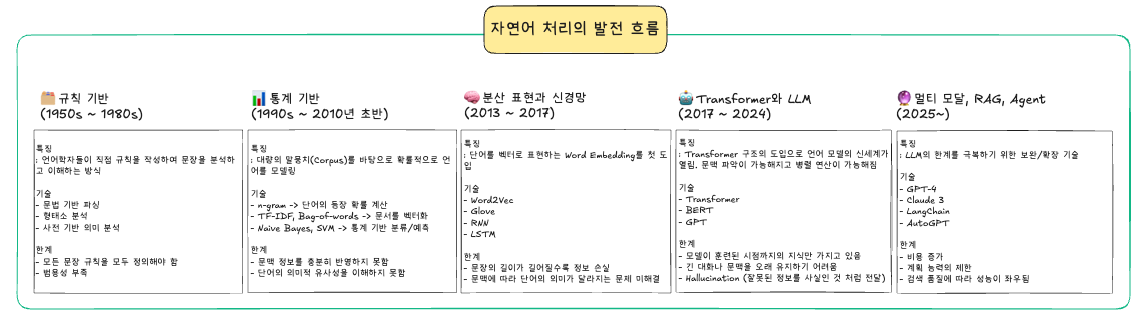

### 자연어 처리 작업 분류

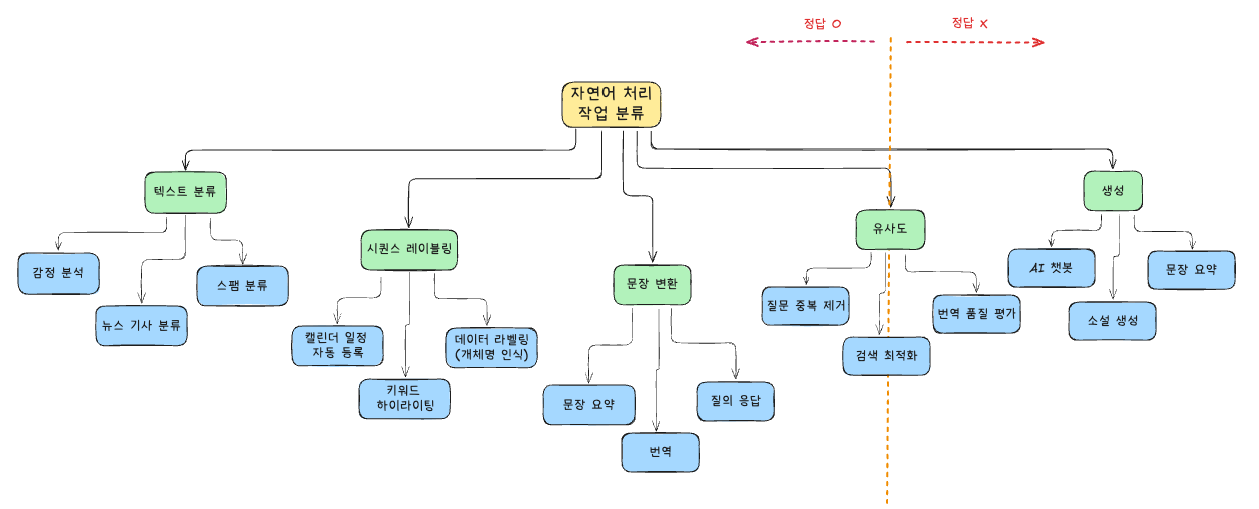